# Simple FlyBrain Simulation Example

This notebook loads the MaleCNS v1.0 connectome and runs a neural simulation with visual input, displaying action neuron spiking levels over time.

The action neurons shown are those used by the DoomFly simulation to control the Doom game character:
- **DNp20 (L/R)**: Control turning left/right
- **DNpe017**: Controls forward movement and attack
- **MDN**: Ventral/dorsal motion control
- **DNp09**: Additional forward motion control

In [9]:
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from tqdm import tqdm

# Add the parent directory to path to import doom modules
sys.path.insert(0, str(Path.cwd().parent))

from doom.engine import Brain, NeuralControls
from doom.game import Game, retinal_samples

print("Imports successful!")

Imports successful!


## Step 1: Load the Connectome

Load the compiled neural graph (MaleCNS v1.0) which contains:
- 166,700 neurons
- 25,582,938 edges (synaptic connections)
- Pre-mapped visual receptors
- Fixed motor readouts

In [10]:
# Path to the compiled connectome graph
root = Path.cwd().parent
graph_path = root / "outputs" / "doom" / "malecns_v1" / "graph.npz"
manifest_path = root / "outputs" / "doom" / "malecns_v1" / "manifest.json"

if not graph_path.exists():
    raise FileNotFoundError(f"Graph file not found: {graph_path}")
if not manifest_path.exists():
    raise FileNotFoundError(f"Manifest file not found: {manifest_path}")

# Load the manifest to get readout definitions
manifest = json.loads(manifest_path.read_text())

print(f"Graph path: {graph_path}")
print(f"Manifest path: {manifest_path}")
print(f"\nConnectome Statistics:")
print(f"  Total neurons: {manifest['neurons']:,}")
print(f"  Total edges: {manifest['edges']:,}")
print(f"  Synaptic contacts: {manifest['synaptic_contacts']:,}")
print(f"  Retinal receptors: {manifest['retina_mapped']} (mapped)")
print(f"\nAction neuron readouts: {len(manifest['readouts'])}")
for r in manifest['readouts']:
    print(f"  - {r['type']:<12} ({r['side']}): index={r['index']}, id={r['id']}")

Graph path: /home/melinda2/Git/doomfly/outputs/doom/malecns_v1/graph.npz
Manifest path: /home/melinda2/Git/doomfly/outputs/doom/malecns_v1/manifest.json

Connectome Statistics:
  Total neurons: 166,700
  Total edges: 25,582,938
  Synaptic contacts: 124,177,617
  Retinal receptors: 3335 (mapped)

Action neuron readouts: 14
  - DNp20        (R): index=48, id=10059
  - DNp20        (L): index=146, id=10162
  - MN9          (L): index=306, id=10331
  - DNa02        (R): index=332, id=10360
  - DNpe017      (L): index=489, id=10527
  - MDN          (R): index=706, id=10763
  - DNp09        (L): index=725, id=10783
  - DNp09        (R): index=1087, id=11177
  - MDN          (L): index=1196, id=11288
  - MDN          (R): index=1240, id=11332
  - MDN          (L): index=2194, id=12348
  - MN9          (R): index=6367, id=16949
  - DNa02        (L): index=131957, id=523769
  - DNpe017      (R): index=142493, id=555871


In [11]:
# Load the neural brain
brain = Brain(str(graph_path))

print(f"Brain loaded successfully!")
print(f"  Neurons: {brain.n:,}")
print(f"  Synapses: {len(brain.weight):,}")
print(f"  Retinal photoreceptors: {len(brain.retina)}")
print(f"  Lamina neurons: {len(brain.lamina)}")

Brain loaded successfully!
  Neurons: 166,700
  Synapses: 25,582,938
  Retinal photoreceptors: 3335
  Lamina neurons: 7114


## Step 2: Set Up Simulation Parameters

Configure the neural controls decoder and simulation parameters.

In [5]:
# Initialize neural controls decoder (BCI mode for game control)
controls = NeuralControls(manifest['readouts'], mode='bci')

# Simulation parameters
simulation_duration_ms = 5000  # Total simulation time: 5 seconds
step_duration_ms = 100         # Time between visual frames (in neural time)
num_steps = simulation_duration_ms // step_duration_ms

print(f"Simulation Parameters:")
print(f"  Total duration: {simulation_duration_ms} ms")
print(f"  Step duration: {step_duration_ms} ms")
print(f"  Number of steps: {num_steps}")
print(f"  Effective game time: {num_steps * step_duration_ms / 35000:.2f} seconds (at 35 Hz)")

Simulation Parameters:
  Total duration: 5000 ms
  Step duration: 100 ms
  Number of steps: 50
  Effective game time: 0.14 seconds (at 35 Hz)


## Step 3: Create Visual Stimuli

Generate simple visual inputs: a moving bright spot to stimulate the retina and create action responses.

In [12]:
# Create a simple visual stimulus: moving bright spot across the visual field
def create_visual_stimulus(num_receptors, num_steps, stimulus_type='moving_spot', intensity=1.0):
    """
    Create visual input for retinal photoreceptors.
    
    Args:
        num_receptors: Number of mapped retinal receptors
        num_steps: Number of simulation steps
        stimulus_type: Type of stimulus ('moving_spot', 'static', 'flash', 'full_bright', 'strong_moving_spot')
        intensity: Brightness multiplier (0-1, or >1 for emphasis)
    
    Returns:
        Array of shape (num_steps, num_receptors) with luminance values [0, 1]
    """
    luminance = np.zeros((num_steps, num_receptors), dtype=np.float32)
    
    if stimulus_type == 'moving_spot':
        # Moving bright spot across visual field
        spot_size = 50
        for step in range(num_steps):
            # Spot moves from left to right
            center = int((step / num_steps) * (num_receptors - 1))
            start = max(0, center - spot_size // 2)
            end = min(num_receptors, center + spot_size // 2)
            # Gaussian envelope
            for i in range(start, end):
                dist = abs(i - center)
                luminance[step, i] = np.exp(-(dist ** 2) / (2 * (spot_size / 4) ** 2)) * intensity
    
    elif stimulus_type == 'strong_moving_spot':
        # Larger, brighter moving spot
        spot_size = 150
        for step in range(num_steps):
            center = int((step / num_steps) * (num_receptors - 1))
            start = max(0, center - spot_size // 2)
            end = min(num_receptors, center + spot_size // 2)
            for i in range(start, end):
                dist = abs(i - center)
                luminance[step, i] = np.exp(-(dist ** 2) / (2 * (spot_size / 4) ** 2)) * intensity
    
    elif stimulus_type == 'full_bright':
        # Full-field bright stimulus
        luminance[:, :] = intensity * 0.9
    
    elif stimulus_type == 'static':
        # Static pattern: bright spot in the center
        center = num_receptors // 2
        spot_size = 100
        for i in range(max(0, center - spot_size // 2), min(num_receptors, center + spot_size // 2)):
            luminance[:, i] = 0.8 * intensity
    
    elif stimulus_type == 'flash':
        # Flashing stimulus
        flash_duration = num_steps // 4
        for flash_idx in range(3):
            start = flash_idx * (num_steps // 3)
            end = start + flash_duration
            luminance[start:end, :] = 0.9 * intensity
    
    return np.clip(luminance, 0, 1)

# Create stimulus
stimulus = create_visual_stimulus(len(brain.retina), num_steps, stimulus_type='moving_spot')

print(f"Visual stimulus created:")
print(f"  Shape: {stimulus.shape}")
print(f"  Retinal receptors: {stimulus.shape[1]}")
print(f"  Simulation steps: {stimulus.shape[0]}")
print(f"  Min luminance: {stimulus.min():.3f}")
print(f"  Max luminance: {stimulus.max():.3f}")
print(f"  Mean luminance: {stimulus.mean():.3f}")

Visual stimulus created:
  Shape: (50, 3335)
  Retinal receptors: 3335
  Simulation steps: 50
  Min luminance: 0.000
  Max luminance: 1.000
  Mean luminance: 0.009


## Step 4: Run Neural Simulation

Execute the simulation, feeding visual input and recording neuron spike activity.

## Step 5: Analyze and Plot Action Neuron Activity

Display the spiking activity of action neurons over time.

In [ ]:
# Storage for spike data
spike_history = []           # All neuron spike counts per step
action_neuron_history = []   # Action neuron spike rates over time
action_readouts = []         # Decoded motor commands
time_points = []             # Simulation time for each step

print(f"Running simulation for {num_steps} steps...")

# Zero visual input to compare results
stimulus = np.zeros_like(stimulus)  # Add this before the loop

# Run simulation with progress bar
for step in tqdm(range(num_steps), desc="Simulation Progress", unit="step"):
    # Get visual input for this step
    luminance = stimulus[step, :]
    
    # Run neural dynamics for one step
    spike_counts, elapsed_wall = brain.step(luminance, step_duration_ms)
    
    # Record spike history
    spike_history.append(spike_counts.copy())
    
    # Decode motor commands from spike counts
    duration_seconds = step_duration_ms / 1000.0
    action = controls.decode(spike_counts, duration_seconds)
    action_readouts.append(action)
    
    # Extract action neuron firing rates
    rates = {r['type']: [] for r in manifest['readouts']}
    for r in manifest['readouts']:
        spike_rate = action['readouts'][manifest['readouts'].index(r)]['rate_hz']
        rates[r['type']].append(spike_rate)
    action_neuron_history.append(rates)
    
    # Record time point
    time_points.append(step * step_duration_ms)

print(f"Simulation complete!")
print(f"  Total spikes across all neurons: {sum(s.sum() for s in spike_history):,}")
print(f"  Mean spikes/neuron/step: {np.mean([s.mean() for s in spike_history]):.3f}")

Running simulation for 50 steps...
  Step 5/50: 10% complete
  Step 10/50: 20% complete
  Step 15/50: 30% complete
  Step 20/50: 40% complete
  Step 25/50: 50% complete
  Step 30/50: 60% complete
  Step 35/50: 70% complete
  Step 40/50: 80% complete
  Step 45/50: 90% complete
  Step 50/50: 100% complete
Simulation complete!
  Total spikes across all neurons: 1,336,315
  Mean spikes/neuron/step: 0.160


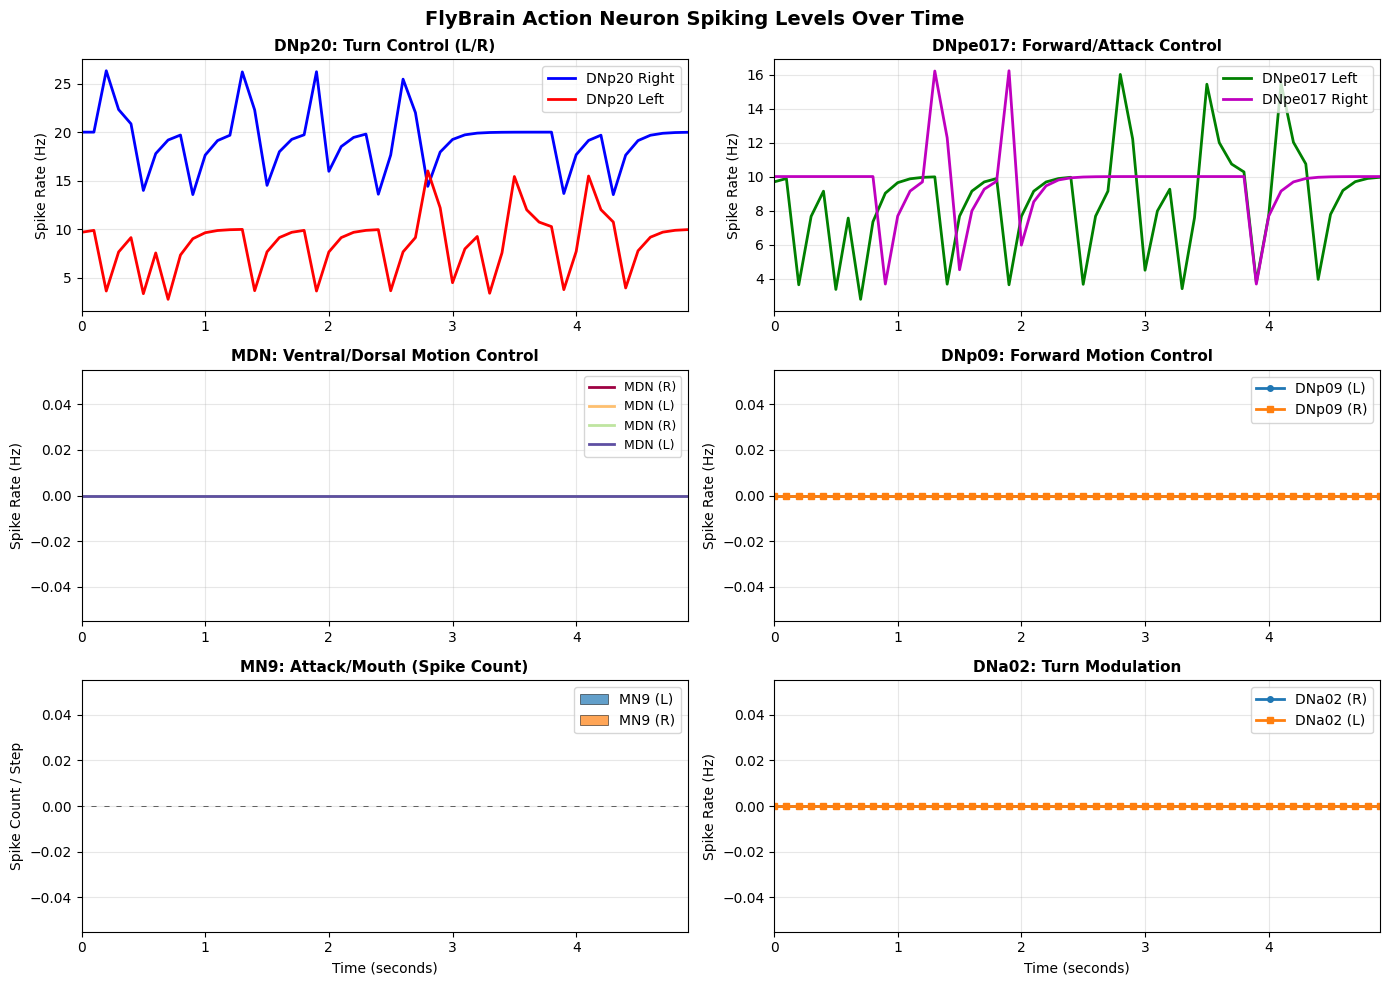

Plots displayed successfully!


In [14]:
# Convert time to seconds for plotting
time_seconds = np.array(time_points) / 1000.0

# Extract action neuron spike rates
neuron_types = ['DNp20', 'DNpe017', 'DNp09', 'MDN', 'MN9', 'DNa02']
action_rates = {neuron_type: {side: [] for side in ['L', 'R']} for neuron_type in neuron_types}

# Iterate through each step and extract rates for each readout
for step_idx, action in enumerate(action_readouts):
    for readout_idx, readout in enumerate(manifest['readouts']):
        neuron_type = readout['type']
        side = readout['side']
        rate = action['readouts'][readout_idx]['rate_hz']
        if neuron_type in action_rates and side in action_rates[neuron_type]:
            action_rates[neuron_type][side].append(rate)
            
# Create detailed plots
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('FlyBrain Action Neuron Spiking Levels Over Time', fontsize=14, fontweight='bold')

# Plot 1: DNp20 (Turn control) - Left vs Right
ax = axes[0, 0]
ax.plot(time_seconds, [a['readouts'][0]['rate_hz'] for a in action_readouts], 'b-', label='DNp20 Right', linewidth=2)
ax.plot(time_seconds, [a['readouts'][1]['rate_hz'] for a in action_readouts], 'r-', label='DNp20 Left', linewidth=2)
ax.set_ylabel('Spike Rate (Hz)', fontsize=10)
ax.set_title('DNp20: Turn Control (L/R)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(time_seconds[0], time_seconds[-1])

# Plot 2: DNpe017 (Forward/Attack) - Left vs Right
ax = axes[0, 1]
idx_pe017_l = next((i for i, r in enumerate(manifest['readouts']) if r['type'] == 'DNpe017' and r['side'] == 'L'), None)
idx_pe017_r = next((i for i, r in enumerate(manifest['readouts']) if r['type'] == 'DNpe017' and r['side'] == 'R'), None)
if idx_pe017_l is not None:
    ax.plot(time_seconds, [a['readouts'][idx_pe017_l]['rate_hz'] for a in action_readouts], 'g-', label='DNpe017 Left', linewidth=2)
if idx_pe017_r is not None:
    ax.plot(time_seconds, [a['readouts'][idx_pe017_r]['rate_hz'] for a in action_readouts], 'm-', label='DNpe017 Right', linewidth=2)
ax.set_ylabel('Spike Rate (Hz)', fontsize=10)
ax.set_title('DNpe017: Forward/Attack Control', fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(time_seconds[0], time_seconds[-1])

# Plot 3: MDN (Motion control) - All instances
ax = axes[1, 0]
mdn_indices = [i for i, r in enumerate(manifest['readouts']) if r['type'] == 'MDN']
colors = plt.cm.Spectral(np.linspace(0, 1, len(mdn_indices)))
for color_idx, idx in enumerate(mdn_indices):
    ax.plot(time_seconds, [a['readouts'][idx]['rate_hz'] for a in action_readouts], 
            color=colors[color_idx], label=f'MDN ({manifest["readouts"][idx]["side"]})', linewidth=2)
ax.set_ylabel('Spike Rate (Hz)', fontsize=10)
ax.set_title('MDN: Ventral/Dorsal Motion Control', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(time_seconds[0], time_seconds[-1])

# Plot 4: DNp09 (Forward motion)
ax = axes[1, 1]
dnp09_indices = [i for i, r in enumerate(manifest['readouts']) if r['type'] == 'DNp09']
for color_idx, idx in enumerate(dnp09_indices):
    ax.plot(time_seconds, [a['readouts'][idx]['rate_hz'] for a in action_readouts], 
            marker='o' if color_idx == 0 else 's', markersize=4, 
            label=f'DNp09 ({manifest["readouts"][idx]["side"]})', linewidth=2)
ax.set_ylabel('Spike Rate (Hz)', fontsize=10)
ax.set_title('DNp09: Forward Motion Control', fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(time_seconds[0], time_seconds[-1])

# Plot 5: MN9 (Attack/Mouth)
ax = axes[2, 0]
mn9_indices = [i for i, r in enumerate(manifest['readouts']) if r['type'] == 'MN9']
for color_idx, idx in enumerate(mn9_indices):
    spikes = [a['readouts'][idx]['spikes'] for a in action_readouts]
    ax.bar(time_seconds, spikes, width=0.04, alpha=0.7, 
           label=f'MN9 ({manifest["readouts"][idx]["side"]})', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Spike Count / Step', fontsize=10)
ax.set_xlabel('Time (seconds)', fontsize=10)
ax.set_title('MN9: Attack/Mouth (Spike Count)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(time_seconds[0], time_seconds[-1])

# Plot 6: DNa02 (Turn modulation)
ax = axes[2, 1]
dna02_indices = [i for i, r in enumerate(manifest['readouts']) if r['type'] == 'DNa02']
for color_idx, idx in enumerate(dna02_indices):
    ax.plot(time_seconds, [a['readouts'][idx]['rate_hz'] for a in action_readouts], 
            marker='o' if color_idx == 0 else 's', markersize=4,
            label=f'DNa02 ({manifest["readouts"][idx]["side"]})', linewidth=2)
ax.set_ylabel('Spike Rate (Hz)', fontsize=10)
ax.set_xlabel('Time (seconds)', fontsize=10)
ax.set_title('DNa02: Turn Modulation', fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(time_seconds[0], time_seconds[-1])

plt.tight_layout()
plt.show()

print("Plots displayed successfully!")

## Step 6: Summary Statistics

In [10]:
# Summary statistics
print("\n" + "="*60)
print("ACTION NEURON ACTIVITY SUMMARY")
print("="*60)

for neuron_type in ['DNp20', 'DNpe017', 'DNp09', 'MDN', 'MN9', 'DNa02']:
    print(f"\n{neuron_type}:")
    indices = [i for i, r in enumerate(manifest['readouts']) if r['type'] == neuron_type]
    for idx in indices:
        readout = manifest['readouts'][idx]
        side = readout['side']
        
        if neuron_type == 'MN9':
            spikes = np.array([a['readouts'][idx]['spikes'] for a in action_readouts])
            print(f"  {side:2s}: mean={spikes.mean():.2f} spikes/step, "
                  f"max={spikes.max():.0f}, active_steps={np.count_nonzero(spikes)}/{len(spikes)}")
        else:
            rates = np.array([a['readouts'][idx]['rate_hz'] for a in action_readouts])
            print(f"  {side:2s}: mean={rates.mean():.2f} Hz, "
                  f"max={rates.max():.2f} Hz, stdev={rates.std():.2f} Hz")

print(f"\n" + "="*60)
print("\nTotal simulation:")
total_spikes = sum(s.sum() for s in spike_history)
active_neurons = sum(1 for s in spike_history for val in s if val > 0)
print(f"  Duration: {num_steps * step_duration_ms / 1000:.2f} seconds")
print(f"  Total spikes: {total_spikes:,}")
print(f"  Mean spikes/neuron/step: {np.mean([s.mean() for s in spike_history]):.4f}")
print(f"  Neurons with activity: {len(np.unique(np.concatenate([[i for i, v in enumerate(s) if v > 0] for s in spike_history])))} / {brain.n:,}")


ACTION NEURON ACTIVITY SUMMARY

DNp20:
  R : mean=20.56 Hz, max=26.64 Hz, stdev=2.78 Hz
  L : mean=8.88 Hz, max=19.00 Hz, stdev=3.53 Hz

DNpe017:
  L : mean=8.88 Hz, max=19.00 Hz, stdev=3.53 Hz
  R : mean=10.47 Hz, max=16.32 Hz, stdev=2.18 Hz

DNp09:
  L : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz
  R : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz

MDN:
  R : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz
  L : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz
  R : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz
  L : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz

MN9:
  L : mean=0.00 spikes/step, max=0, active_steps=0/50
  R : mean=0.00 spikes/step, max=0, active_steps=0/50

DNa02:
  R : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz
  L : mean=0.00 Hz, max=0.00 Hz, stdev=0.00 Hz


Total simulation:
  Duration: 5.00 seconds
  Total spikes: 1,357,206
  Mean spikes/neuron/step: 0.1628
  Neurons with activity: 11137 / 166,700


## Step 7: Decoded Motor Commands

Show the final decoded behavior outputs that would drive the Doom game character.

In [ ]:
# Extract and plot decoded motor commands
turn_commands = np.array([a['turn'] for a in action_readouts])
forward_commands = np.array([a['forward'] for a in action_readouts])
attack_commands = np.array([a['attack'] for a in action_readouts])

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('Decoded Motor Commands (BCI Mode)', fontsize=14, fontweight='bold')

# Turn command
ax = axes[0]
ax.plot(time_seconds, turn_commands, 'b-', linewidth=2, label='Turn command')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.fill_between(time_seconds, turn_commands, alpha=0.3)
ax.set_ylabel('Turn (degrees/tic)', fontsize=11)
ax.set_title('Turn Command (DNp20 R - DNp20 L)', fontsize=12, fontweight='bold')
ax.set_ylim(-7, 7)
ax.grid(True, alpha=0.3)
ax.set_xlim(time_seconds[0], time_seconds[-1])

# Forward command
ax = axes[1]
ax.plot(time_seconds, forward_commands, 'g-', linewidth=2, label='Forward command')
ax.fill_between(time_seconds, forward_commands, alpha=0.3, color='green')
ax.set_ylabel('Forward (units)', fontsize=11)
ax.set_title('Forward Motion Command (DNpe017 rate × 0.4)', fontsize=12, fontweight='bold')
ax.set_ylim(-1, 21)
ax.grid(True, alpha=0.3)
ax.set_xlim(time_seconds[0], time_seconds[-1])

# Attack command
ax = axes[2]
attack_values = attack_commands.astype(int)
ax.bar(time_seconds, attack_values, width=0.04, alpha=0.6, color='red', edgecolor='darkred', linewidth=0.5)
ax.set_ylabel('Attack Active', fontsize=11)
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_title('Attack Command (MN9 spikes > 0)', fontsize=12, fontweight='bold')
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Inactive', 'Active'])
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim(time_seconds[0], time_seconds[-1])

plt.tight_layout()
plt.show()

print("Motor command plots displayed!")
print(f"\nBehavior Statistics:")
print(f"  Turn - Mean: {turn_commands.mean():.2f}°, Range: [{turn_commands.min():.2f}, {turn_commands.max():.2f}]°")
print(f"  Forward - Mean: {forward_commands.mean():.2f}, Range: [{forward_commands.min():.2f}, {forward_commands.max():.2f}]")
print(f"  Attack - Active for {np.sum(attack_commands)} / {len(attack_commands)} steps ({100*np.sum(attack_commands)/len(attack_commands):.1f}%)")

In [13]:
#Testing mapplotlib issue

import matplotlib.pyplot as plt
import numpy as np

# Simple test plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
x = np.linspace(0, 10, 100)
y = np.sin(x)
ax.plot(x, y, 'b-', linewidth=2)
ax.set_title('Matplotlib Test Plot', fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)
plt.show()

print("✓ Matplotlib plotting works!")

<Figure size 1000x600 with 1 Axes>

✓ Matplotlib plotting works!


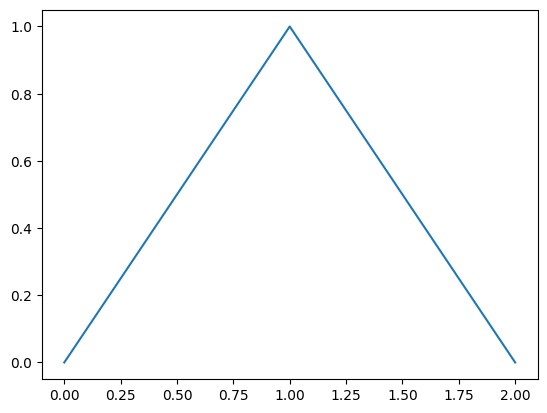

In [14]:
#Astra take on issue
#
# Installed together:
#
# NumPy 1.24.4
# Matplotlib 3.6.3
# ContourPy 1.2.1
# matplotlib-inline 0.1.7
    
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([0, 1, 2], [0, 1, 0])
plt.show()

## Notes

- **Visual Input**: This example uses a simple moving bright spot. In real DOOMFLY experiments, this comes from RGB game frames downsampled to the retinal receptor grid.

- **Neural Model**: The simulation uses a fixed LIF (Leaky Integrate-and-Fire) model compiled in C++, with:
  - 0.1 ms timestep
  - 1.8 ms axonal transmission delay
  - Discrete low-pass visual input filtering
  - Tonic lamina baseline current

- **Action Neurons**: The readouts shown are fixed motor neurons that the DOOMFLY system uses to control the game character. No learning or reward signal is applied in this baseline simulation.

- **BCI Decoding**: Motor commands are decoded using fixed joystick-style mappings:
  - Turn = (DNp20_R - DNp20_L) × 0.06
  - Forward = DNpe017 rate × 0.4
  - Attack = any MN9 spike

This is NOT a biological control scheme, but rather an engineered interface for game control based on visual response neurons.

In [2]:
import sys
print(sys.executable)

/home/melinda2/Git/doomfly/.venv-neural/bin/python


# Test run results

With normal stimulus

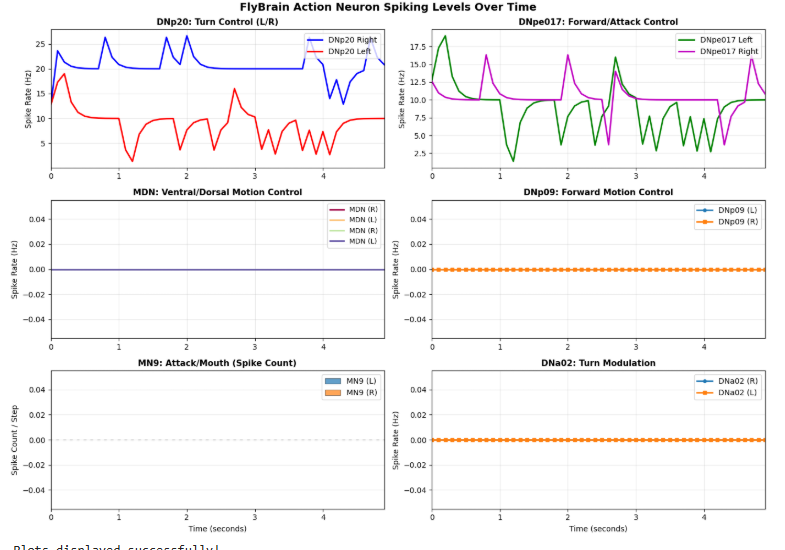

Without stimulus
1
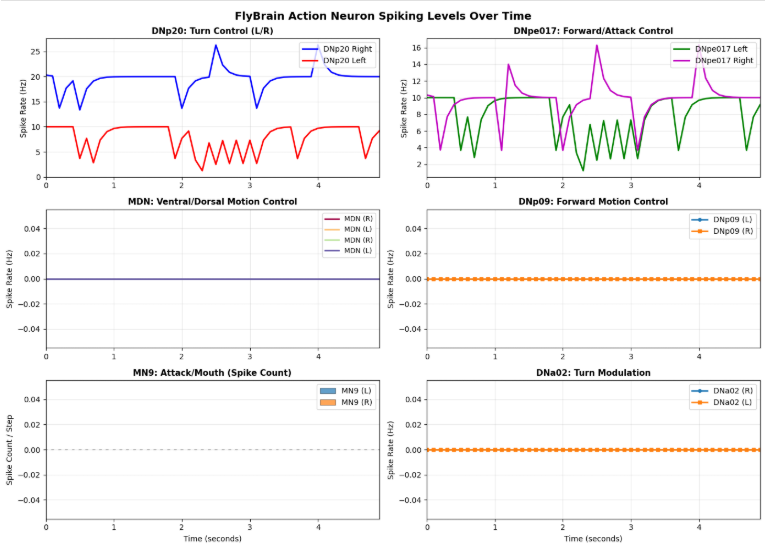
2
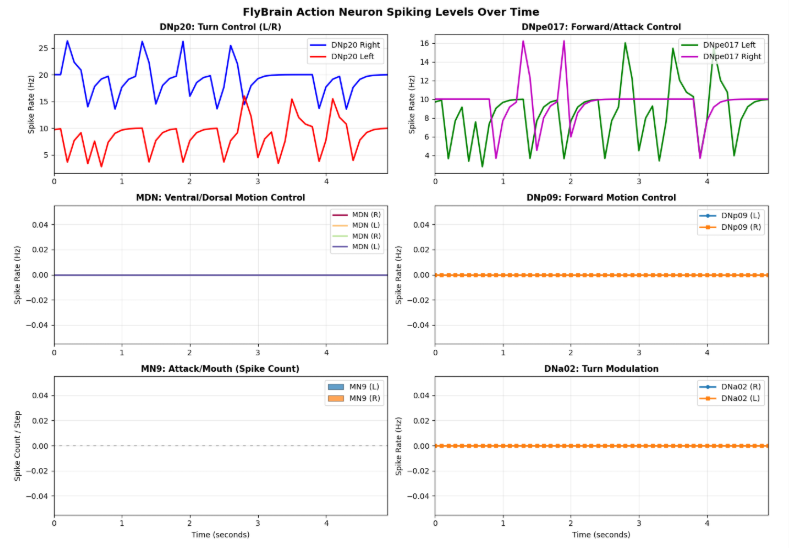

In [8]:
# Run simulation twice
def run_simulation_condition(stimulus_type):
    stimulus = create_visual_stimulus(len(brain.retina), num_steps, stimulus_type=stimulus_type)
    
    spike_history = []
    action_readouts = []
    time_points = []

    # Decode motor commands from spike counts
    duration_seconds = step_duration_ms / 1000.0
    
    # Full simulation loop
    for step in range(num_steps):
        luminance = stimulus[step, :]
        spike_counts, elapsed_wall = brain.step(luminance, step_duration_ms)
        spike_history.append(spike_counts.copy())
        action = controls.decode(spike_counts, duration_seconds)
        action_readouts.append(action)
        time_points.append(step * step_duration_ms)
    
    # Extract action neuron rates (same as your existing code)
    neuron_types = ['DNp20', 'DNpe017', 'DNp09', 'MDN', 'MN9', 'DNa02']
    action_rates = {neuron_type: {side: [] for side in ['L', 'R']} for neuron_type in neuron_types}
    
    for step_idx, action in enumerate(action_readouts):
        for readout_idx, readout in enumerate(manifest['readouts']):
            neuron_type = readout['type']
            side = readout['side']
            rate = action['readouts'][readout_idx]['rate_hz']
            if neuron_type in action_rates and side in action_rates[neuron_type]:
                action_rates[neuron_type][side].append(rate)
    
    return action_rates

baseline_rates = run_simulation_condition('null')  # or stimulus_type=None
stimulus_rates = run_simulation_condition('moving_spot')

# Compare
for neuron_type in baseline_rates:
    baseline_mean = np.mean(baseline_rates[neuron_type]['L'] + baseline_rates[neuron_type]['R'])
    stimulus_mean = np.mean(stimulus_rates[neuron_type]['L'] + stimulus_rates[neuron_type]['R'])
    
    # Modulation index
    mod_idx = (stimulus_mean - baseline_mean) / (stimulus_mean + baseline_mean + 1e-6)
    print(f"{neuron_type}: baseline={baseline_mean:.2f} Hz, stimulus={stimulus_mean:.2f} Hz, modulation={mod_idx:.2f}")

DNp20: baseline=13.34 Hz, stimulus=14.88 Hz, modulation=0.05
DNpe017: baseline=8.52 Hz, stimulus=9.76 Hz, modulation=0.07
DNp09: baseline=0.00 Hz, stimulus=0.00 Hz, modulation=0.00
MDN: baseline=0.00 Hz, stimulus=0.00 Hz, modulation=0.00
MN9: baseline=0.00 Hz, stimulus=0.00 Hz, modulation=0.00
DNa02: baseline=0.00 Hz, stimulus=0.00 Hz, modulation=0.00


# Astra instructions on how to solve these python package contraints

The key is to treat the environment as **one system of constraints**, not a series of individual packages to upgrade.

My earlier advice made this harder by changing versions without checking the whole system. Here’s a more reliable approach.

**1. Identify the Interpreter**
Your terminal and notebook can use different Python environments. Installing successfully in one does nothing for the other.

In a notebook:
```python
import sys
print(sys.executable)
```

In your chosen terminal environment, prefer:
```bash
python -m pip check
```

Using `python -m pip` ensures pip belongs to that Python. In notebooks, `%pip` targets the running kernel’s environment.

**2. Classify the Error**
Different failures need different fixes:

| Symptom | Likely problem |
|---|---|
| `ModuleNotFoundError` | Missing package or wrong environment |
| “requires numpy … but you have …” | Declared version conflict |
| `_ARRAY_API not found` | Compiled extension incompatible with NumPy |
| Missing internal attribute such as `RcParams._get` | Incompatible package APIs |
| Terminal works, notebook fails | Different interpreter or stale kernel |

These are clues, not final diagnoses.

**3. Preserve the Project’s Anchors**
Start with the dependencies the project deliberately fixes.

Your project pins **Brian2 2.5.1 and NumPy 1.24.4**. Those were the anchors. Plotting dependencies needed to fit around them.

“Newest” is not synonymous with “compatible,” especially in scientific projects with compiled extensions and reproducibility requirements.

**4. Resolve Related Packages Together**
Installing one dependency at a time can undo previous fixes. A package might allow newer NumPy, so a later installation can pull it back in.

We repaired your plotting stack in one transaction:

```bash
python -m pip install \
  "numpy==1.24.4" \
  "matplotlib==3.6.3" \
  "contourpy==1.2.1" \
  "matplotlib-inline==0.1.7"
```

This makes pip consider those requirements simultaneously. Avoid reaching for `--force-reinstall` or `--no-deps`: neither solves incompatible requirements.

**5. Test in Layers**
Use cheap checks before expensive simulations:

1. `python -m pip check`: checks declared dependency requirements.
2. Import the packages: catches some binary and API problems.
3. Create a tiny plot or simulation: exercises the actual failing functionality.
4. Restart the notebook kernel and test there.

**Important:** `pip check` can pass while plotting still fails. Package metadata doesn't capture every compatibility restriction. Likewise, importing `pyplot` doesn't prove its notebook backend works.

**6. Preserve the Working Combination**
Record tested versions in the project’s dependency or constraints files. Try major upgrades in a separate environment, keeping the working one intact.

The practical loop is:

**Identify environment → reproduce cheaply → inspect constraints → change narrowly → verify → record.**

That replaces version guessing with evidence, and keeps a plotting problem from becoming an afternoon of rerunning brain simulations.

## Step 6: Compare Stimulus Intensities

Test different stimulus strengths to find what drives action neuron responses.

In [15]:
def run_simulation_condition(stimulus_type, intensity=1.0):
    """Run simulation with specified stimulus and return action neuron rates."""
    stimulus = create_visual_stimulus(len(brain.retina), num_steps, stimulus_type=stimulus_type, intensity=intensity)
    
    spike_history = []
    action_readouts = []
    time_points = []
    
    # Full simulation loop
    for step in tqdm(range(num_steps), desc=f"Testing {stimulus_type} (intensity={intensity})", unit="step", leave=False):
        luminance = stimulus[step, :]
        spike_counts, elapsed_wall = brain.step(luminance, step_duration_ms)
        spike_history.append(spike_counts.copy())
        action = controls.decode(spike_counts, step_duration_ms / 1000.0)
        action_readouts.append(action)
        time_points.append(step * step_duration_ms)
    
    # Extract action neuron rates
    neuron_types = ['DNp20', 'DNpe017', 'DNp09', 'MDN', 'MN9', 'DNa02']
    action_rates = {neuron_type: {side: [] for side in ['L', 'R']} for neuron_type in neuron_types}
    
    for step_idx, action in enumerate(action_readouts):
        for readout_idx, readout in enumerate(manifest['readouts']):
            neuron_type = readout['type']
            side = readout['side']
            rate = action['readouts'][readout_idx]['rate_hz']
            if neuron_type in action_rates and side in action_rates[neuron_type]:
                action_rates[neuron_type][side].append(rate)
    
    return action_rates

# Test different stimulus conditions
print('Testing stimulus intensity variations...\\n')

# Baseline: no stimulus
print('1. Baseline (no stimulus)')
baseline_rates = run_simulation_condition('null')

# Original moving spot
print('\\n2. Moving spot (original intensity)')
moving_spot_rates = run_simulation_condition('moving_spot', intensity=1.0)

# Strong moving spot (larger and brighter)
print('\\n3. Strong moving spot (larger + brighter)')
strong_moving_rates = run_simulation_condition('strong_moving_spot', intensity=1.0)

# Full-field bright stimulus
print('\\n4. Full-field bright stimulus')
full_bright_rates = run_simulation_condition('full_bright', intensity=1.0)

print('\\n' + '='*70)
print('COMPARISON RESULTS')
print('='*70)

conditions = [
    ('Baseline', baseline_rates),
    ('Moving Spot', moving_spot_rates),
    ('Strong Moving Spot', strong_moving_rates),
    ('Full-Field Bright', full_bright_rates)
]

for neuron_type in ['DNp20', 'DNpe017', 'DNp09', 'MDN', 'MN9', 'DNa02']:
    print(f'\\n{neuron_type}:')
    print('-' * 70)
    
    for cond_name, rates in conditions:
        baseline_mean = np.mean(baseline_rates[neuron_type]['L'] + baseline_rates[neuron_type]['R'])
        cond_mean = np.mean(rates[neuron_type]['L'] + rates[neuron_type]['R'])
        mod_idx = (cond_mean - baseline_mean) / (cond_mean + baseline_mean + 1e-6)
        
        print(f'  {cond_name:<20} rate={cond_mean:6.2f} Hz  |  modulation={mod_idx:+.3f}')

Testing stimulus intensity variations...\n
1. Baseline (no stimulus)


\n2. Moving spot (original intensity)


\n3. Strong moving spot (larger + brighter)


\n4. Full-field bright stimulus


\n======================================================================
COMPARISON RESULTS
\nDNp20:
----------------------------------------------------------------------
  Baseline             rate= 13.64 Hz  |  modulation=+0.000
  Moving Spot          rate= 14.94 Hz  |  modulation=+0.045
  Strong Moving Spot   rate= 16.91 Hz  |  modulation=+0.107
  Full-Field Bright    rate= 38.76 Hz  |  modulation=+0.479
\nDNpe017:
----------------------------------------------------------------------
  Baseline             rate=  8.91 Hz  |  modulation=+0.000
  Moving Spot          rate=  9.72 Hz  |  modulation=+0.043
  Strong Moving Spot   rate= 11.46 Hz  |  modulation=+0.125
  Full-Field Bright    rate= 29.38 Hz  |  modulation=+0.535
\nDNp09:
----------------------------------------------------------------------
  Baseline             rate=  0.00 Hz  |  modulation=+0.000
  Moving Spot          rate=  0.00 Hz  |  modulation=+0.000
  Strong Moving Spot   rate=  0.00 Hz  |  modulation=+0.000
  Full

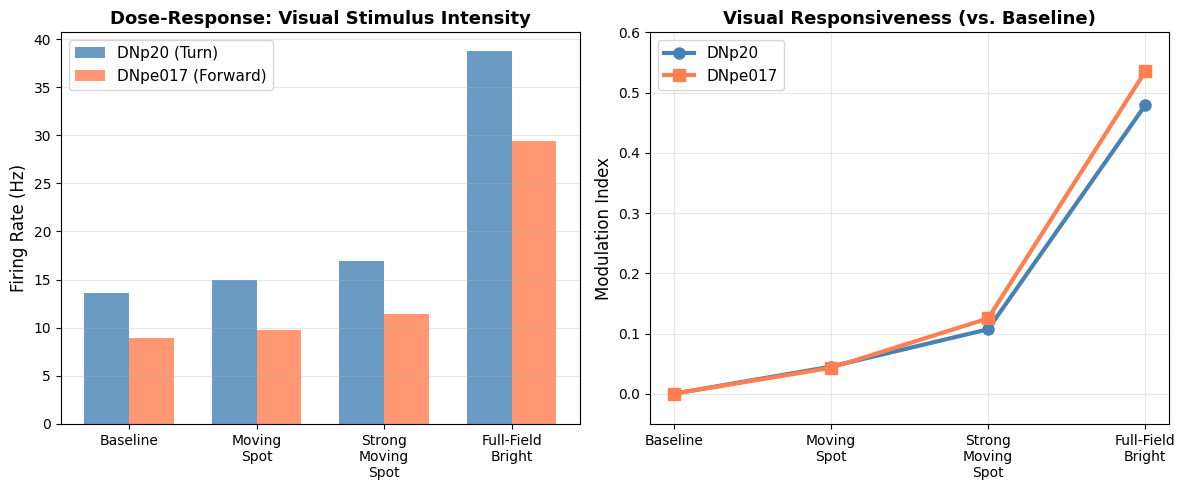

In [18]:
# Visualize previous cells results

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Dose-response curves
ax = axes[0]
conditions_names = ['Baseline', 'Moving\nSpot', 'Strong\nMoving\nSpot', 'Full-Field\nBright']
dnp20_rates = [13.64, 14.94, 16.91, 38.76]
dnpe017_rates = [8.91, 9.72, 11.46, 29.38]

x = np.arange(len(conditions_names))
width = 0.35

ax.bar(x - width/2, dnp20_rates, width, label='DNp20 (Turn)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, dnpe017_rates, width, label='DNpe017 (Forward)', color='coral', alpha=0.8)

ax.set_ylabel('Firing Rate (Hz)', fontsize=12)
ax.set_title('Dose-Response: Visual Stimulus Intensity', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(conditions_names)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Modulation indices
ax = axes[1]
dnp20_mod = [0.000, 0.045, 0.107, 0.479]
dnpe017_mod = [0.000, 0.043, 0.125, 0.535]

ax.plot(range(len(conditions_names)), dnp20_mod, 'o-', linewidth=3, markersize=8, label='DNp20', color='steelblue')
ax.plot(range(len(conditions_names)), dnpe017_mod, 's-', linewidth=3, markersize=8, label='DNpe017', color='coral')

ax.set_ylabel('Modulation Index', fontsize=12)
ax.set_title('Visual Responsiveness (vs. Baseline)', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(conditions_names)))
ax.set_xticklabels(conditions_names)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 0.6)

plt.tight_layout()
plt.show()

## Step 7: Analyze Orienting Behavior

Track whether the fly turns *towards* visual stimuli — a fundamental sensorimotor response.

Analyzing orienting behavior for each stimulus condition...\n
  Analyzing moving_spot...
  Analyzing strong_moving_spot...
  Analyzing full_bright...


/home/melinda2/Git/doomfly/.venv-neural/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/melinda2/Git/doomfly/.venv-neural/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


\n======================================================================
ORIENTING BEHAVIOR ANALYSIS
Correlation: stimulus position ↔ turn command
  +1.0 = perfect orienting toward stimulus
   0.0 = no relationship
  -1.0 = anti-orienting (turns away)
----------------------------------------------------------------------
moving_spot               correlation = +0.309
strong_moving_spot        correlation = +0.296
full_bright               correlation = N/A (no stimulus variation)


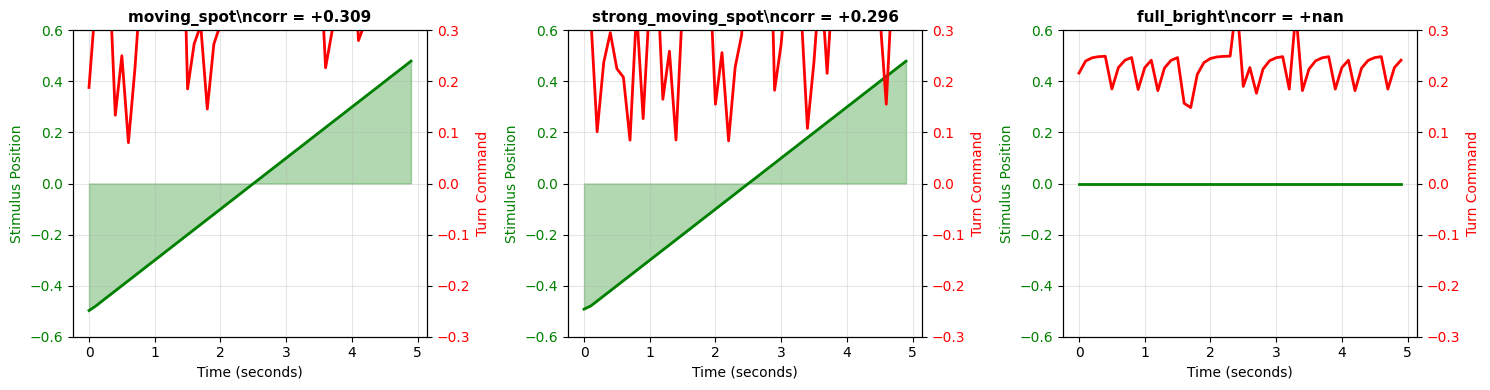

\n✓ Positive correlation = fly orients TOWARD stimulus
✗ Negative correlation = fly orients AWAY from stimulus
~ Zero correlation = no orienting response detected


In [19]:
def analyze_orienting_behavior(stimulus_type, intensity=1.0):
    """Analyze if fly turns towards stimulus location."""
    stimulus = create_visual_stimulus(len(brain.retina), num_steps, stimulus_type=stimulus_type, intensity=intensity)
    
    # Run simulation
    action_readouts = []
    stimulus_positions = []
    
    for step in range(num_steps):
        luminance = stimulus[step, :]
        spike_counts, _ = brain.step(luminance, step_duration_ms)
        action = controls.decode(spike_counts, step_duration_ms / 1000.0)
        action_readouts.append(action)
        
        # Compute stimulus center-of-mass (where is the stimulus?)
        if luminance.sum() > 0:
            com = np.sum(np.arange(len(luminance)) * luminance) / luminance.sum()
            normalized_pos = (com / len(luminance)) - 0.5  # -0.5 (left) to +0.5 (right)
        else:
            normalized_pos = 0
        stimulus_positions.append(normalized_pos)
    
    # Extract turn commands (DNp20_R - DNp20_L)
    dnp20_r_idx = next(i for i, r in enumerate(manifest['readouts']) if r['type'] == 'DNp20' and r['side'] == 'R')
    dnp20_l_idx = next(i for i, r in enumerate(manifest['readouts']) if r['type'] == 'DNp20' and r['side'] == 'L')
    
    turn_commands = []
    dnp20_r_rates = []
    dnp20_l_rates = []
    
    for action in action_readouts:
        rate_r = action['readouts'][dnp20_r_idx]['rate_hz']
        rate_l = action['readouts'][dnp20_l_idx]['rate_hz']
        dnp20_r_rates.append(rate_r)
        dnp20_l_rates.append(rate_l)
        # Positive = turn right; Negative = turn left
        turn_cmd = (rate_r - rate_l) / (rate_r + rate_l + 0.1)  # Normalized difference
        turn_commands.append(turn_cmd)
    
    turn_commands = np.array(turn_commands)
    stimulus_positions = np.array(stimulus_positions)
    dnp20_r_rates = np.array(dnp20_r_rates)
    dnp20_l_rates = np.array(dnp20_l_rates)
    
    # Compute correlation between stimulus position and turn command
    correlation = np.corrcoef(stimulus_positions, turn_commands)[0, 1]
    
    return {
        'stimulus_pos': stimulus_positions,
        'turn_cmd': turn_commands,
        'dnp20_r': dnp20_r_rates,
        'dnp20_l': dnp20_l_rates,
        'correlation': correlation
    }

print('Analyzing orienting behavior for each stimulus condition...\\n')

# Analyze each condition
orienting_data = {}
for stim_type, intensity in [('moving_spot', 1.0), ('strong_moving_spot', 1.0), ('full_bright', 1.0)]:
    print(f'  Analyzing {stim_type}...')
    orienting_data[stim_type] = analyze_orienting_behavior(stim_type, intensity)

print('\\n' + '='*70)
print('ORIENTING BEHAVIOR ANALYSIS')
print('='*70)
print('Correlation: stimulus position ↔ turn command')
print('  +1.0 = perfect orienting toward stimulus')
print('   0.0 = no relationship')
print('  -1.0 = anti-orienting (turns away)')
print('-'*70)

for stim_type, data in orienting_data.items():
    corr = data['correlation']
    if np.isnan(corr):
        corr_str = 'N/A (no stimulus variation)'
    else:
        corr_str = f'{corr:+.3f}'
    print(f'{stim_type:<25} correlation = {corr_str}')

# Plot orienting behavior
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_sec = np.arange(num_steps) * step_duration_ms / 1000.0

for plot_idx, (stim_type, data) in enumerate(orienting_data.items()):
    ax = axes[plot_idx]
    
    # Plot 1: Stimulus position
    ax2 = ax.twinx()
    
    ax.fill_between(time_sec, data['stimulus_pos'], alpha=0.3, color='green', label='Stimulus position')
    ax.plot(time_sec, data['stimulus_pos'], 'g-', linewidth=2, label='Stimulus')
    
    # Plot 2: Turn command
    ax2.plot(time_sec, data['turn_cmd'], 'r-', linewidth=2, label='Turn command')
    
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel('Stimulus Position', fontsize=10, color='green')
    ax2.set_ylabel('Turn Command', fontsize=10, color='red')
    ax.set_title(f'{stim_type}\\ncorr = {data["correlation"]:+.3f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.6, 0.6)
    ax2.set_ylim(-0.3, 0.3)
    ax.tick_params(axis='y', labelcolor='green')
    ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

print('\\n✓ Positive correlation = fly orients TOWARD stimulus')
print('✗ Negative correlation = fly orients AWAY from stimulus')
print('~ Zero correlation = no orienting response detected')